In [1]:
#!pip install download
from download import download

#!wget -c https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/datasets/intermediate/Canidae_data.zip

#download(dataset_url, "./datasets-Canidae", kind="zip", replace=True)


In [2]:
#!unzip Canidae_data.zip

### Loading dataset

In [3]:
batch_size = 18                             
image_size = 224                            
num_epochs = 10                             
lr = 0.001                                  
momentum = 0.9                              
workers = 4                                 


In [4]:
import mindspore as ms
import mindspore.dataset as ds
import mindspore.dataset.vision as vision

# Dataset path
data_path_train = "./data/Canidae/train/"
data_path_val = "./data/Canidae/val/"

# create training dataset

def create_dataset_canidae(dataset_path, usage):
    """Data Loading"""
    data_set = ds.ImageFolderDataset(dataset_path,
                                     num_parallel_workers=workers,
                                     shuffle=True,)

    # transform operations
    mean = [0.485 * 255, 0.456 * 255, 0.406 * 255]
    std = [0.229 * 255, 0.224 * 255, 0.225 * 255]
    scale = 32

    if usage == "train":
        # operations for training dataset
        trans = [
            vision.RandomCropDecodeResize(size=image_size, scale=(0.08, 1.0), ratio=(0.75, 1.333)),
            vision.RandomHorizontalFlip(prob=0.5),
            vision.Normalize(mean=mean, std=std),
            vision.HWC2CHW()
        ]
    else:
        # map operations for inference dataset
        trans = [
            vision.Decode(),
            vision.Resize(image_size + scale),
            vision.CenterCrop(image_size),
            vision.Normalize(mean=mean, std=std),
            vision.HWC2CHW()
        ]


    #  mapping operations
    data_set = data_set.map(
        operations=trans,
        input_columns='image',
        num_parallel_workers=workers)


    #  operation
    data_set = data_set.batch(batch_size)

    return data_set


dataset_train = create_dataset_canidae(data_path_train, "train")
step_size_train = dataset_train.get_dataset_size()

dataset_val = create_dataset_canidae(data_path_val, "val")
step_size_val = dataset_val.get_dataset_size()


### Data Visualization

In [5]:
data=next(dataset_train.create_dict_iterator())
labels=data["label"]
images=data["image"]

print("Tensor of image:", images.shape)
print("Labels:", labels)


Tensor of image: (18, 3, 224, 224)
Labels: [0 0 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 0]


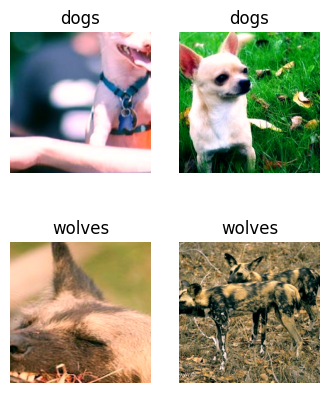

In [6]:
import matplotlib.pyplot as plt
import numpy as np
class_name={0:"dogs", 1:"wolves"}
plt.figure(figsize=(4,5))
for i in range(4):
    data_image=images[i].asnumpy()
    data_label=labels[i]
    # Processing images for display
    data_image=np.transpose(data_image, (1,2,0))
    mean=np.array([0.485, 0.456,0.406])
    std=np.array([0.299,0.224,0.225])
    data_image=std*data_image+mean
    data_image=np.clip(data_image,0,1)
    
    #Display image
    plt.subplot(2,2,i+1)
    plt.imshow(data_image)
    plt.title(class_name[int(labels[i].asnumpy())])
    plt.axis("off")
    
plt.show()    

### Training models

In [7]:
from typing import Type, Union, List, Optional
from mindspore import nn, train
from mindspore.common.initializer import Normal

weight_init=Normal(mean=0, sigma=0.02)
gamma_init=Normal(mean=1, sigma=0.02)

class ResidualBlockBase(nn.Cell):
    expansion:int=1
    def __init__(self, in_channel:int, out_channel:int, stride:int=1, norm:Optional[nn.Cell]= None,
                down_sample:Optional[nn.Cell]=None)->None:
        super(ResidualBlockBase, self).__init__()
        if not norm:
            self.norm=nn.BatchNorm2d(out_channel)
        else:
            self.norm=norm
            
        self.conv1=nn.Conv2d(in_channel, out_channel, kernel_size=3 , stride=stride, weight_init=weight_init)
        self.conv2=nn.Conv2(in_channel, out_channel,kernel_size=3, weight_init=weight_init)
        self.relu=nn.ReLU()
        self.down_sample=down_sample
        
    def construct(self, x):
        identity=x
        out=self.conv1(x)
        out=self.norm(out)
        out=self.relu(out)
        out=self.conv2(out)
        out=self.norm(out)
        
        if down_sample is not None:
            identity=self.down_sample(x)
        out+=identity
        out=self.relu(out)
        return out
        

In [8]:
class ResidualBlock(nn.Cell):
    expansion = 4  

    def __init__(self, in_channel: int, out_channel: int,
                 stride: int = 1, down_sample: Optional[nn.Cell] = None) -> None:
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channel, out_channel,
                               kernel_size=1, weight_init=weight_init)
        self.norm1 = nn.BatchNorm2d(out_channel)
        self.conv2 = nn.Conv2d(out_channel, out_channel,
                               kernel_size=3, stride=stride,
                               weight_init=weight_init)
        self.norm2 = nn.BatchNorm2d(out_channel)
        self.conv3 = nn.Conv2d(out_channel, out_channel * self.expansion,
                               kernel_size=1, weight_init=weight_init)
        self.norm3 = nn.BatchNorm2d(out_channel * self.expansion)

        self.relu = nn.ReLU()
        self.down_sample = down_sample

    def construct(self, x):

        identity = x  

        out = self.conv1(x)  
        out = self.norm1(out)
        out = self.relu(out)
        out = self.conv2(out)  
        out = self.norm2(out)
        out = self.relu(out)
        out = self.conv3(out)  
        out = self.norm3(out)

        if self.down_sample is not None:
            identity = self.down_sample(x)

        out += identity  
        out = self.relu(out)

        return out


In [14]:
def make_layer(last_out_channel, block:Type[Union[ResidualBlockBase, ResidualBlock]], channel:int, block_nums:int, stride:int=1):
    down_sample=None
    
    if stride!=1 or last_out_channel!=channel*block.expansion:
        down_sample=nn.SequentialCell([
            nn.Conv2d(last_out_channel, channel*block.expansion, kernel_size=1, stride=stride, weight_init=weight_init),
            nn.BatchNorm2d(channel*block.expansion, gamma_init=gamma_init)
            
        ])
    layers=[]
    layers.append(block(last_out_channel, channel, stride=stride, down_sample=down_sample))
    in_channel=channel*block.expansion
    for _ in range(1, block_nums):
        layers.append(block(in_channel, channel))
    return nn.SequentialCell(layers)

In [10]:
from mindspore import load_checkpoint, load_param_into_net


class ResNet(nn.Cell):
    def __init__(self, block: Type[Union[ResidualBlockBase, ResidualBlock]],
                 layer_nums: List[int], num_classes: int, input_channel: int) -> None:
        super(ResNet, self).__init__()

        self.relu = nn.ReLU()
        # The first convolutional layer, with the number of input channel is 3 (color image) and the number of output channel is 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, weight_init=weight_init)
        self.norm = nn.BatchNorm2d(64)
        # Max pooling layer to reduce the size of the image
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, pad_mode='same')
        # Definitions of each residual network structure block
        self.layer1 = make_layer(64, block, 64, layer_nums[0])
        self.layer2 = make_layer(64 * block.expansion, block, 128, layer_nums[1], stride=2)
        self.layer3 = make_layer(128 * block.expansion, block, 256, layer_nums[2], stride=2)
        self.layer4 = make_layer(256 * block.expansion, block, 512, layer_nums[3], stride=2)
        # Average pooling layer
        self.avg_pool = nn.AvgPool2d()
        # flatten layer
        self.flatten = nn.Flatten()
        # Fully-connected layer
        self.fc = nn.Dense(in_channels=input_channel, out_channels=num_classes)

    def construct(self, x):

        x = self.conv1(x)
        x = self.norm(x)
        x = self.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = self.flatten(x)
        x = self.fc(x)

        return x





In [11]:
# Run in terminal or a cell:
!mkdir -p ./LoadPretrainedModel
!wget "https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/models/application/resnet50_224_new.ckpt" -O ./LoadPretrainedModel/resnet50_224_new.ckpt --timeout=60

--2026-02-25 04:46:42--  https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/models/application/resnet50_224_new.ckpt
Resolving proxy.modelarts.com (proxy.modelarts.com)... 192.168.0.180
Connecting to proxy.modelarts.com (proxy.modelarts.com)|192.168.0.180|:80... connected.
Proxy request sent, awaiting response... 200 OK
Length: 102453570 (98M) [binary/octet-stream]
Saving to: ‘./LoadPretrainedModel/resnet50_224_new.ckpt’

./LoadPretrainedMod 100%[===================>]  97.71M  31.9MB/s    in 3.2s    

2026-02-25 04:46:45 (30.2 MB/s) - ‘./LoadPretrainedModel/resnet50_224_new.ckpt’ saved [102453570/102453570]



In [16]:
import os
def _resnet(model_url, block, layers, num_classes, pretrained, pretrained_ckpt, input_channel):
    model = ResNet(block, layers, num_classes, input_channel)
    
    if pretrained:
        if not os.path.exists(pretrained_ckpt):
            download(url=model_url, path=pretrained_ckpt, replace=True)
        param_dict = load_checkpoint(pretrained_ckpt)
        load_param_into_net(model, param_dict)
    
    return model


def resnet50(num_classes: int = 1000, pretrained: bool = False):
    "ResNet50 model"
    resnet50_url = "https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/notebook/models/application/resnet50_224_new.ckpt"
    resnet50_ckpt = "./LoadPretrainedModel/resnet50_224_new.ckpt"
    return _resnet(resnet50_url, ResidualBlock, [3, 4, 6, 3], num_classes,
                   pretrained, resnet50_ckpt, 2048)

### Fine tuning model

In [17]:
import mindspore as ms

network = resnet50(pretrained=True)

in_channels = network.fc.in_channels
head = nn.Dense(in_channels, 2)
network.fc = head

# Average pooling layer kernel size is 7
avg_pool = nn.AvgPool2d(kernel_size=7)
network.avg_pool = avg_pool


# Define optimizer and loss function
opt = nn.Momentum(params=network.trainable_params(), learning_rate=lr, momentum=momentum)
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')

model = train.Model(network, loss_fn, opt, metrics={"Accuracy": train.Accuracy()})

def forward_fn(inputs, targets):

    logits = network(inputs)
    loss = loss_fn(logits, targets)

    return loss

grad_fn = ms.value_and_grad(forward_fn, None, opt.parameters)

def train_step(inputs, targets):

    loss, grads = grad_fn(inputs, targets)
    opt(grads)

    return loss



In [18]:
### Training and evaluation 
# Create the iterator
data_loader_train = dataset_train.create_tuple_iterator(num_epochs=num_epochs)

# Optimal model save path
best_ckpt_dir = "./BestCheckpoint"
best_ckpt_path = "./BestCheckpoint/resnet50-best.ckpt"



In [19]:
import os
import time

# Start circuit training
print("Start Training Loop ...")

best_acc = 0

for epoch in range(num_epochs):
    losses = []
    network.set_train()

    epoch_start = time.time()

    # Reads in data for each training round
    for i, (images, labels) in enumerate(data_loader_train):
        labels = labels.astype(ms.int32)
        loss = train_step(images, labels)
        losses.append(loss)

    # Verify the accuracy after each epoch

    acc = model.eval(dataset_val)['Accuracy']

    epoch_end = time.time()
    epoch_seconds = (epoch_end - epoch_start) * 1000
    step_seconds = epoch_seconds/step_size_train

    print("-" * 20)
    print("Epoch: [%3d/%3d], Average Train Loss: [%5.3f], Accuracy: [%5.3f]" % (
        epoch+1, num_epochs, sum(losses)/len(losses), acc
    ))
    print("epoch time: %5.3f ms, per step time: %5.3f ms" % (
        epoch_seconds, step_seconds
    ))

    if acc > best_acc:
        best_acc = acc
        if not os.path.exists(best_ckpt_dir):
            os.mkdir(best_ckpt_dir)
        ms.save_checkpoint(network, best_ckpt_path)

print("=" * 80)
print(f"End of validation the best Accuracy is: {best_acc: 5.3f}, "
      f"save the best ckpt file in {best_ckpt_path}", flush=True)


Start Training Loop ...
--------------------
Epoch: [  1/ 10], Average Train Loss: [0.587], Accuracy: [1.000]
epoch time: 54659.032 ms, per step time: 3904.217 ms
--------------------
Epoch: [  2/ 10], Average Train Loss: [0.297], Accuracy: [1.000]
epoch time: 69997.579 ms, per step time: 4999.827 ms
--------------------
Epoch: [  3/ 10], Average Train Loss: [0.245], Accuracy: [1.000]
epoch time: 60416.635 ms, per step time: 4315.474 ms
--------------------
Epoch: [  4/ 10], Average Train Loss: [0.185], Accuracy: [1.000]
epoch time: 62180.301 ms, per step time: 4441.450 ms
--------------------
Epoch: [  5/ 10], Average Train Loss: [0.118], Accuracy: [1.000]
epoch time: 58685.834 ms, per step time: 4191.845 ms
--------------------
Epoch: [  6/ 10], Average Train Loss: [0.081], Accuracy: [1.000]
epoch time: 64710.274 ms, per step time: 4622.162 ms
--------------------
Epoch: [  7/ 10], Average Train Loss: [0.057], Accuracy: [1.000]
epoch time: 63163.939 ms, per step time: 4511.710 ms
---

### Visualizing the model prediction

In [28]:
import matplotlib.pyplot as plt
import mindspore as ms

def visualize_model(best_ckpt_path, val_ds):
    net=resnet50()
    in_channels=net.fc.in_channels
    head=nn.Dense(in_channels,2)
    net.fc=head
    avg_pool = nn.AvgPool2d(kernel_size=7)
    net.avg_pool=avg_pool
    
    param_dict=ms.load_checkpoint(best_ckpt_path)
    ms.load_param_into_net(net, param_dict)
    model=train.Model(net)
    
    #Load the model parameters
    param_dict=ms.load_checkpoint(best_ckpt_path)
    ms.load_param_into_net(net, param_dict)
    model=train.Model(net)
    

    data = next(val_ds.create_dict_iterator())
    images = data["image"].asnumpy()
    labels = data["label"].asnumpy()
    class_name = {0: "dogs", 1: "wolves"}
    # Predicted image categories
    output = model.predict(ms.Tensor(data['image']))
    pred = np.argmax(output.asnumpy(), axis=1)

    # Display images and predicted values of images
    plt.figure(figsize=(5, 5))
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        # If the prediction is correct, the display is blue, and if the prediction is wrong, the display is red
        color = 'blue' if pred[i] == labels[i] else 'red'
        plt.title('predict:{}'.format(class_name[pred[i]]), color=color)
        picture_show = np.transpose(images[i], (1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        picture_show = std * picture_show + mean
        picture_show = np.clip(picture_show, 0, 1)
        plt.imshow(picture_show)
        plt.axis('off')

    plt.show()
    


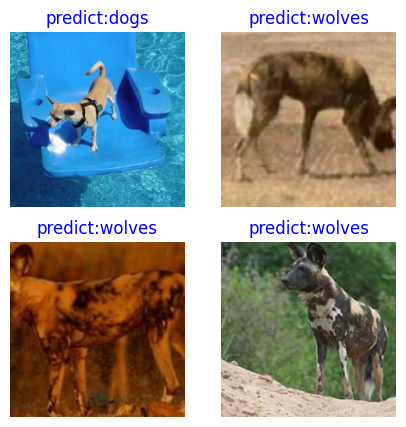

In [29]:
visualize_model(best_ckpt_path, dataset_val)


### Training with fixed Features

In [30]:
net_work = resnet50(pretrained=True)

# Size of fully-connected layer input layer
in_channels = net_work.fc.in_channels
head = nn.Dense(in_channels, 2)
net_work.fc = head
avg_pool = nn.AvgPool2d(kernel_size=7)
net_work.avg_pool = avg_pool

# Freeze all parameters except the last layer
for param in net_work.get_parameters():
    if param.name not in ["fc.weight", "fc.bias"]:
        param.requires_grad = False

# Define optimizer and loss function
opt = nn.Momentum(params=net_work.trainable_params(), learning_rate=lr, momentum=0.5)
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')


def forward_fn(inputs, targets):
    logits = net_work(inputs)
    loss = loss_fn(logits, targets)

    return loss

grad_fn = ms.value_and_grad(forward_fn, None, opt.parameters)

def train_step(inputs, targets):
    loss, grads = grad_fn(inputs, targets)
    opt(grads)
    return loss

# Instantiate models
model1 = train.Model(net_work, loss_fn, opt, metrics={"Accuracy": train.Accuracy()})


### Training Evaluation

In [31]:
dataset_train = create_dataset_canidae(data_path_train, "train")
step_size_train = dataset_train.get_dataset_size()

dataset_val = create_dataset_canidae(data_path_val, "val")
step_size_val = dataset_val.get_dataset_size()

num_epochs = 10

# keating Iterators
data_loader_train = dataset_train.create_tuple_iterator(num_epochs=num_epochs)
data_loader_val = dataset_val.create_tuple_iterator(num_epochs=num_epochs)
best_ckpt_dir = "./BestCheckpoint"
best_ckpt_path = "./BestCheckpoint/resnet50-best-freezing-param.ckpt"


In [32]:
# Start circuit training
print("Start Training Loop ...")

best_acc = 0

for epoch in range(num_epochs):
    losses = []
    net_work.set_train()

    epoch_start = time.time()

    for i, (images, labels) in enumerate(data_loader_train):
        labels = labels.astype(ms.int32)
        loss = train_step(images, labels)
        losses.append(loss)


    acc = model1.eval(dataset_val)['Accuracy']

    epoch_end = time.time()
    epoch_seconds = (epoch_end - epoch_start) * 1000
    step_seconds = epoch_seconds/step_size_train

    print("-" * 20)
    print("Epoch: [%3d/%3d], Average Train Loss: [%5.3f], Accuracy: [%5.3f]" % (
        epoch+1, num_epochs, sum(losses)/len(losses), acc
    ))
    print("epoch time: %5.3f ms, per step time: %5.3f ms" % (
        epoch_seconds, step_seconds
    ))

    if acc > best_acc:
        best_acc = acc
        if not os.path.exists(best_ckpt_dir):
            os.mkdir(best_ckpt_dir)
        ms.save_checkpoint(net_work, best_ckpt_path)

print("=" * 80)
print(f"End of validation the best Accuracy is: {best_acc: 5.3f}, "
      f"save the best ckpt file in {best_ckpt_path}", flush=True)


Start Training Loop ...
--------------------
Epoch: [  1/ 10], Average Train Loss: [0.662], Accuracy: [0.917]
epoch time: 23281.918 ms, per step time: 1662.994 ms
--------------------
Epoch: [  2/ 10], Average Train Loss: [0.546], Accuracy: [0.950]
epoch time: 25110.778 ms, per step time: 1793.627 ms
--------------------
Epoch: [  3/ 10], Average Train Loss: [0.490], Accuracy: [0.967]
epoch time: 23907.407 ms, per step time: 1707.672 ms
--------------------
Epoch: [  4/ 10], Average Train Loss: [0.455], Accuracy: [0.967]
epoch time: 25372.470 ms, per step time: 1812.319 ms
--------------------
Epoch: [  5/ 10], Average Train Loss: [0.388], Accuracy: [0.967]
epoch time: 27310.880 ms, per step time: 1950.777 ms
--------------------
Epoch: [  6/ 10], Average Train Loss: [0.370], Accuracy: [0.967]
epoch time: 25179.943 ms, per step time: 1798.567 ms
--------------------
Epoch: [  7/ 10], Average Train Loss: [0.323], Accuracy: [0.983]
epoch time: 24401.535 ms, per step time: 1742.967 ms
---

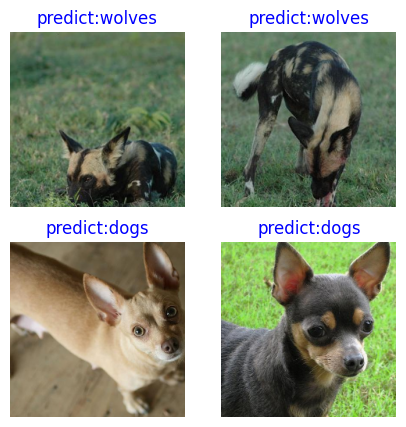

In [33]:
visualize_model(best_ckpt_path, dataset_val)
